# Hollywood by the Numbers: Trends and Patterns in IMDB Ratings and Box Office Data
- Alex Arce: aarce
- Lunden Mandigo: lundenm
- Tyrone Pettygrue: tpetty


## Alex Analysis

### Question

- What is the relationship between the origin of production of a film to the amount of money it grosses?


#### Analysis will include
1. Descriptive Statistics
2. Inferential Statistics
3. Graphical Analysis
4. Comparative Analysis
5. Multivariate Analysis
6. Synthesis
7. Documentation
8. Reporting & Interpretation
9. Reflection

In [1]:
# Loading in neccessary packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore')

In [2]:
# Read in CSV file to create DataFrame
movies = pd.read_csv('movies.csv')



# Creating a new DataFrame using the explode method to get all the movies with multiple production countries and cleaning for blank spaces
movies_expanded = movies.assign(productionCountries=movies['productionCountries'].str.split(',')).explode('productionCountries')
movies_expanded['productionCountries'] = movies_expanded['productionCountries'].str.strip().str.title()


# Getting all the countries means and standard deviation for Domestic and Foreign Gross Revenue
movies_expanded.groupby('productionCountries')[['domesticGross', 'foreignGross', 'worldwideGross']].agg(['mean','std'])


domesticGross                foreignGross  \
                                  mean           std          mean   
productionCountries                                                  
Algeria                   3.207000e+05           NaN  2.264300e+07   
Argentina                 4.005980e+06  6.066552e+06  3.106690e+07   
Australia                 4.462983e+07  4.468630e+07  5.380649e+07   
Austria                   5.755767e+06  6.517976e+06  2.746711e+07   
Bahamas                   5.353320e+07  3.339569e+07  3.145859e+07   
...                                ...           ...           ...   
Ukraine                   0.000000e+00  0.000000e+00  2.206056e+07   
United Arab Emirates      2.737870e+07  3.190732e+07  3.743386e+07   
United Kingdom            4.466511e+07  7.653040e+07  8.140617e+07   
United States Of America  6.322070e+07  8.380800e+07  8.342607e+07   
Vietnam                   1.667350e+06  4.576196e+06  1.483460e+07   

                                       worldwideGross                
                                   std           mean           std  
productionCountries                                                  
Algeria                            NaN   2.296370e+07           NaN  
Argentina                 1.848397e+07   3.507288e+07  2.070323e+07  
Australia                 6.194262e+07   9.843633e+07  1.008609e+08  
Austria                   3.533941e+07   3.322287e+07  3.902563e+07  
Bahamas                   1.908282e+07   8.499179e+07  5.247851e+07  
...                                ...            ...           ...  
Ukraine                   5.777912e+06   2.206056e+07  5.777912e+06  
United Arab Emirates      5.165421e+07   6.481256e+07  6.432160e+07  
United Kingdom            1.561182e+08   1.260716e+08  2.272901e+08  
United States Of America  1.468841e+08   1.466471e+08  2.234270e+08  
Vietnam                   6.305768e+06   1.650195e+07  7.770450e+06  

[75 rows x 6 columns]

In [3]:
# Getting the top 10 countries with the most amount of films produced
movies_expanded.groupby('productionCountries').size().nlargest(10).sort_values(ascending=False)


productionCountries
United States Of America    4556
United Kingdom               878
France                       631
Japan                        540
China                        535
Germany                      474
South Korea                  361
Canada                       352
Hong Kong                    262
India                        248
dtype: int64

In [4]:
# Creating a DataFrame with the top 10 countries with the most films produced

# Count number of movies per country
country_counts = movies_expanded.groupby('productionCountries').size()

# Getting the top 10 countries (by movie count)
top10_countries = country_counts.nlargest(10).index

# Filtering the original DataFrame to include only from countries in the top 10
top10_df = movies_expanded[movies_expanded['productionCountries'].isin(top10_countries)]

# Creating Log Transformation for better visuals
top10_df['log_worldwideGross'] = np.log(top10_df['worldwideGross'] + 1)



# Multiple Linear Regression

In [5]:
# Linear regression of where a film is produced to worldwide gross(revenue)


# This automatically handles categorical variables.
model = smf.ols('worldwideGross ~ C(productionCountries)', data=top10_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         worldwideGross   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     37.81
Date:                Tue, 18 Mar 2025   Prob (F-statistic):           1.52e-66
Time:                        22:10:17   Log-Likelihood:            -1.8088e+05
No. Observations:                8837   AIC:                         3.618e+05
Df Residuals:                    8827   BIC:                         3.618e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

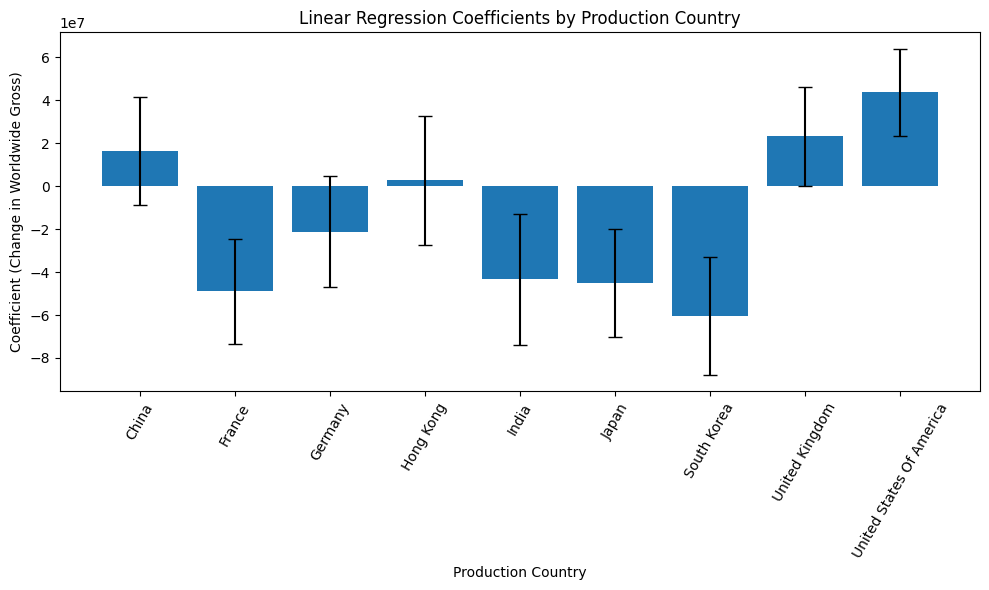

In [6]:
# Visual Representation of Linear Regression

# Get coefficients (excluding intercept) and confidence intervals
coefs = model.params.drop('Intercept')
conf_int = model.conf_int().drop('Intercept')

# Remove the prefix/suffix from the index
coefs.index = coefs.index.str.replace(r'C\(productionCountries\)\[T\.', '', regex=True)
coefs.index = coefs.index.str.replace(r'\]', '', regex=True)

conf_int.index = conf_int.index.str.replace(r'C\(productionCountries\)\[T\.', '', regex=True)
conf_int.index = conf_int.index.str.replace(r'\]', '', regex=True)

# Calculate error bars
lower_errors = coefs - conf_int[0]
upper_errors = conf_int[1] - coefs

# Plot
plt.figure(figsize=(10,6))
plt.bar(coefs.index, coefs.values, yerr=[lower_errors, upper_errors], capsize=5)
plt.xticks(rotation=60)
plt.xlabel('Production Country')
plt.ylabel('Coefficient (Change in Worldwide Gross)')
plt.title('Linear Regression Coefficients by Production Country')
plt.tight_layout()
plt.show()

# Explanation of Linear Regression
- The purpose is to measure how much the film's gross changes on average for films from different countries based on the baseline (Canada).
- The variable I used for this regression was 'productionCountries,' and I converted it to be continuous.
- This shows the positive and negative coefficients on which countries have higher or lower gross earnings.

# Anova Testing

In [7]:
# Fit a model using ordinary least squares.

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                              sum_sq      df          F        PR(>F)
C(productionCountries)  1.198030e+19     9.0  37.814775  1.518385e-66
Residual                3.107255e+20  8827.0        NaN           NaN


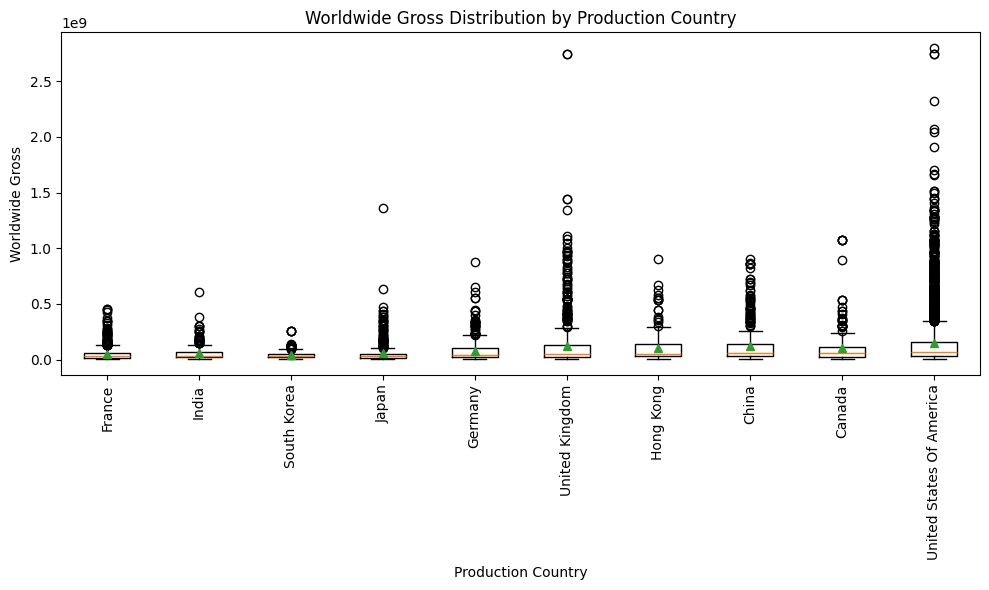

In [8]:
# Visual representation of ANOVA test

# Sort countries by median worldwideGross for clarity
countries_sorted = top10_df.groupby('productionCountries')['worldwideGross'].median().sort_values().index

# Preparing data to create a list of worldwideGross values per country
data_to_plot = [movies_expanded[movies_expanded['productionCountries'] == country]['worldwideGross'] for country in countries_sorted]

plt.figure(figsize=(10,6))
plt.boxplot(data_to_plot, labels=countries_sorted, showmeans=True)
plt.xticks(rotation=90)
plt.xlabel('Production Country')
plt.ylabel('Worldwide Gross')
plt.title('Worldwide Gross Distribution by Production Country')
plt.tight_layout()
plt.show()

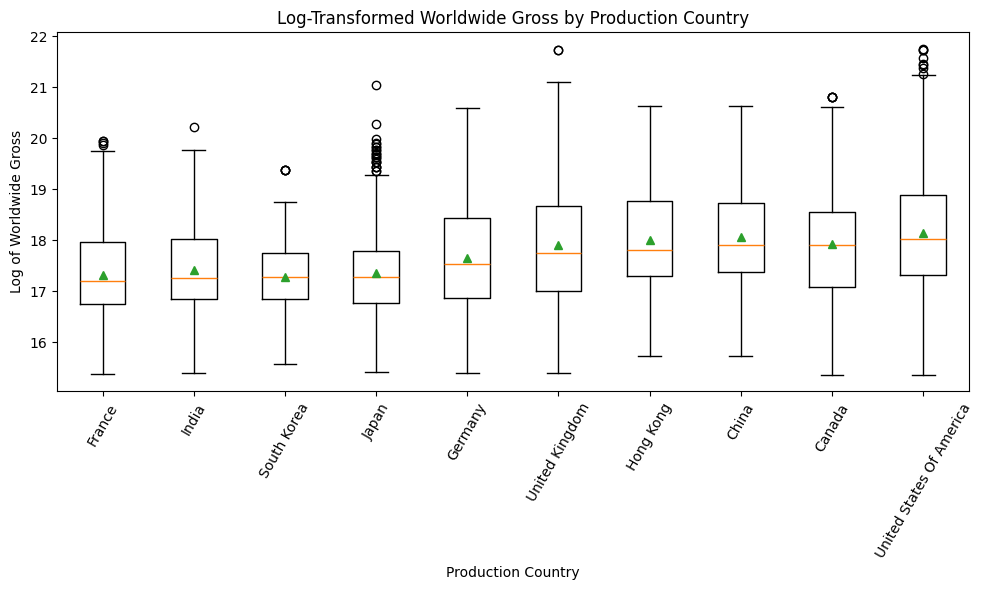

In [9]:

# Creating Log Transformation for better visuals
top10_df['log_worldwideGross'] = np.log(top10_df['worldwideGross'] + 1)

# Visual representation of ANOVA test (Updated)
countries_sorted = (
    top10_df.groupby('productionCountries')['log_worldwideGross']
    .median()
    .sort_values()
    .index
)
data_to_plot = [
    top10_df[top10_df['productionCountries'] == country]['log_worldwideGross']
    for country in countries_sorted
]
plt.figure(figsize=(10,6))
plt.boxplot(data_to_plot, labels=countries_sorted, showmeans=True)
plt.xticks(rotation=60)
plt.xlabel('Production Country')
plt.ylabel('Log of Worldwide Gross')
plt.title('Log-Transformed Worldwide Gross by Production Country')
plt.tight_layout()
plt.show()

# Explanation of ANOVA
- The purpose is to see if there are statistically significant differences in the mean gross across different production countries.
- The variable I used for this ANOVA test was 'productionCountries.'
- The box plots help us see the distribution and spread of gross for each country.


# Chi-Square Test

<Figure size 1000x600 with 0 Axes>

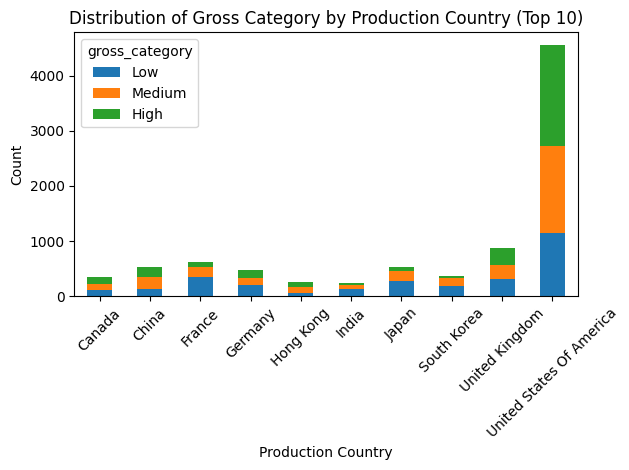

In [10]:
# Bin worldwideGross into 3 categories (Low, Medium, High)
top10_df['gross_category'] = pd.qcut(top10_df['worldwideGross'], q=3, labels=['Low', 'Medium', 'High'])

# Create a contingency table that counts the gross_category for each production country
contingency_table = pd.crosstab(top10_df['productionCountries'], top10_df['gross_category'])



plt.figure(figsize=(10,6))
contingency_table.plot(kind='bar', stacked=True)
plt.xlabel('Production Country')
plt.ylabel('Count')
plt.title('Distribution of Gross Category by Production Country (Top 10)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Perform Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print results
print("Chi-square statistic:", chi2)
print("P-value:", p)



Chi-square statistic: 676.5796353054453
P-value: 5.26928735384469e-132


In [12]:
# Assuming 'gross_category' has already been created in your DataFrame
crosstab_country_gross = pd.crosstab(top10_df['productionCountries'],
                                     top10_df['gross_category'])
print(crosstab_country_gross)

gross_category             Low  Medium  High
productionCountries                         
Canada                     114     105   133
China                      130     215   190
France                     358     168   105
Germany                    211     130   133
Hong Kong                   66     103    93
India                      135      67    46
Japan                      285     182    73
South Korea                192     135    34
United Kingdom             314     253   311
United States Of America  1141    1587  1828


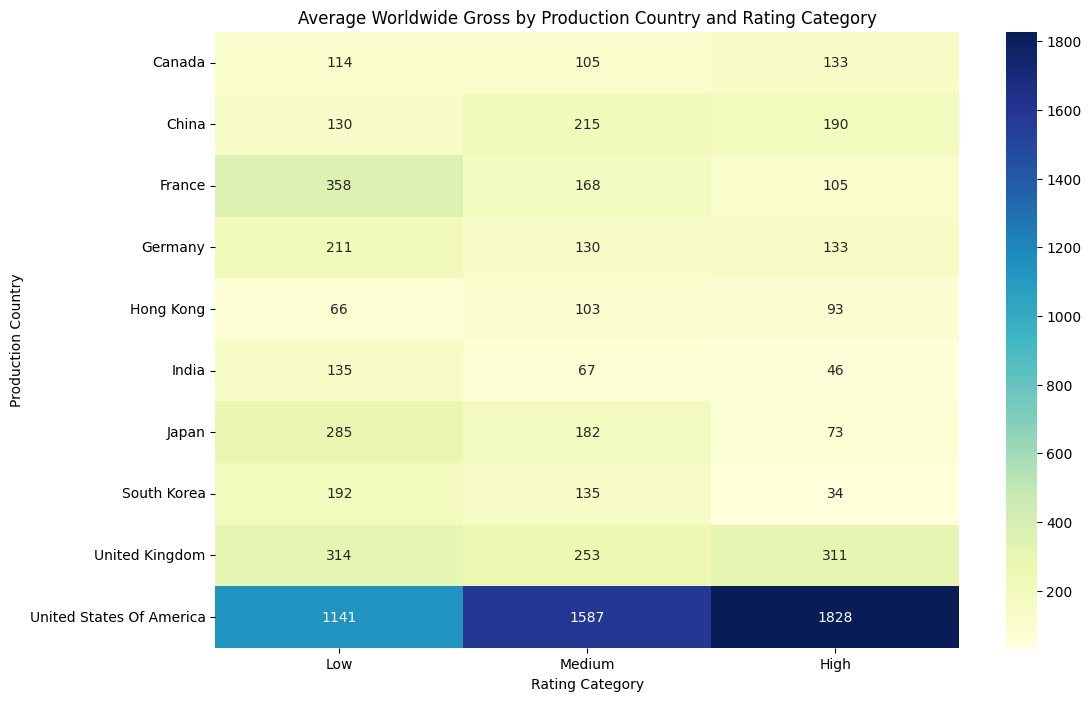

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(crosstab_country_gross, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Average Worldwide Gross by Production Country and Rating Category')
plt.ylabel('Production Country')
plt.xlabel('Rating Category')
plt.show()

# Explanation of Chi-Square Test
- The purpose was to determine if there were any statistically significant differences in the mean gross across different production countries.
- The variables used were 'productionCountries' and 'gross_category.'
- The distribution of gross categories differs by production country.
- The stacked bar chart shows the differences between countries.



# Reflection
#### Challenges:
- As a team, we integrated a new data source into our project. With the introduction of new data, some cleaning was needed to obtain accurate data.
- While calculating descriptive statistics (mean and standard deviation) by country, I noticed inconsistencies due to differing group sizes. To verify this, I manually found Argentina’s mean, which confirmed the issue. Stripping whitespace (strip()) from the ‘productionCountries’ column resolved the discrepancies and ensured consistent results.
- A possible limitation is the data skew, with most films produced in the USA (4,556 entries) compared to the second most films produced in the United Kingdom's 878.

# Lunden's Analysis of Movie Data
### Main RQ
- What is the relationship between IMDB rating and income (domestic vs foreign vs internationl, gross vs %)

## Descriptive Statistics


In [14]:
print(movies.columns)

Index(['title', 'originalTitle', 'isAdult', 'runtimeMinutes', 'genres',
       'IMDBavgRating', 'numVotes', 'rank', 'worldwideGross', 'domesticGross',
       'domestic%', 'foreignGross', 'foreign%', 'year', 'originalLang',
       'productionCountries', 'main_genre', 'rating_category'],
      dtype='object')


In [15]:
movies.describe()

,isAdult,runtimeMinutes,IMDBavgRating,numVotes,rank,worldwideGross,domesticGross,domestic%,foreignGross,foreign%,year
count,7004.000000,7004.000000,7004.000000,7.004000e+03,7004.000000,7.004000e+03,7.004000e+03,7004.00000,7.004000e+03,7004.000000,7004.000000
mean,0.000714,104.654055,6.254326,8.545767e+04,101.490720,1.137223e+08,4.236133e+07,34.84486,7.136074e+07,65.153998,2012.621074
std,0.026711,28.926183,1.147439,1.812764e+05,56.298787,1.911045e+08,7.372391e+07,30.07744,1.271558e+08,30.076601,6.883668
min,0.000000,0.000000,1.200000,5.000000e+00,1.000000,4.693664e+06,0.000000e+00,0.00000,0.000000e+00,0.000000,2001.000000
25%,0.000000,92.000000,5.600000,4.117500e+02,54.000000,2.562145e+07,1.640742e+05,0.30000,1.480998e+07,42.900000,2007.000000
50%,0.000000,104.000000,6.400000,1.043750e+04,102.000000,4.841293e+07,1.830439e+07,36.60000,3.025607e+07,63.400000,2013.000000
75%,0.000000,119.000000,7.000000,9.189450e+04,150.000000,1.126836e+08,5.110049e+07,57.10000,7.030778e+07,99.600000,2019.000000
max,1.000000,700.000000,10.000000,2.985446e+06,200.000000,2.799439e+09,9.366622e+08,100.00000,1.993811e+09,100.000000,2024.000000


In [16]:
def print_median(df):
    '''Prints the median of columns with numeric data types'''

    for column in df.select_dtypes(include=[np.number]).columns:
        print(f'{column}: {df[column].median()}')

print_median(movies)

isAdult: 0.0
runtimeMinutes: 104.0
IMDBavgRating: 6.4
numVotes: 10437.5
rank: 102.0
worldwideGross: 48412933.0
domesticGross: 18304386.5
domestic%: 36.6
foreignGross: 30256068.0
foreign%: 63.4
year: 2013.0


In [17]:
def print_grouped_stats(df):
    '''Prints the grouped stats of columns with numeric data types by rating category'''
    for column in df.select_dtypes(include=[np.number]).columns:
        print(f"{column} stats by rating category")
        print(f"{df.groupby('rating_category')[column].describe()}\n")

print_grouped_stats(movies)

isAdult stats by rating category
                  count      mean       std  min  25%  50%  75%  max
rating_category                                                     
High             1728.0  0.000579  0.024056  0.0  0.0  0.0  0.0  1.0
Low               310.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0
Medium           4966.0  0.000805  0.028372  0.0  0.0  0.0  0.0  1.0

runtimeMinutes stats by rating category
                  count        mean        std  min   25%    50%    75%    max
rating_category                                                               
High             1728.0  110.563657  33.633029  0.0  96.0  114.0  130.0  280.0
Low               310.0   91.416129  32.843126  0.0  83.0   92.0  105.0  163.0
Medium           4966.0  103.424084  26.362317  0.0  92.0  103.0  116.0  700.0

IMDBavgRating stats by rating category
                  count      mean       std  min  25%  50%  75%   max
rating_category                                                      
High  

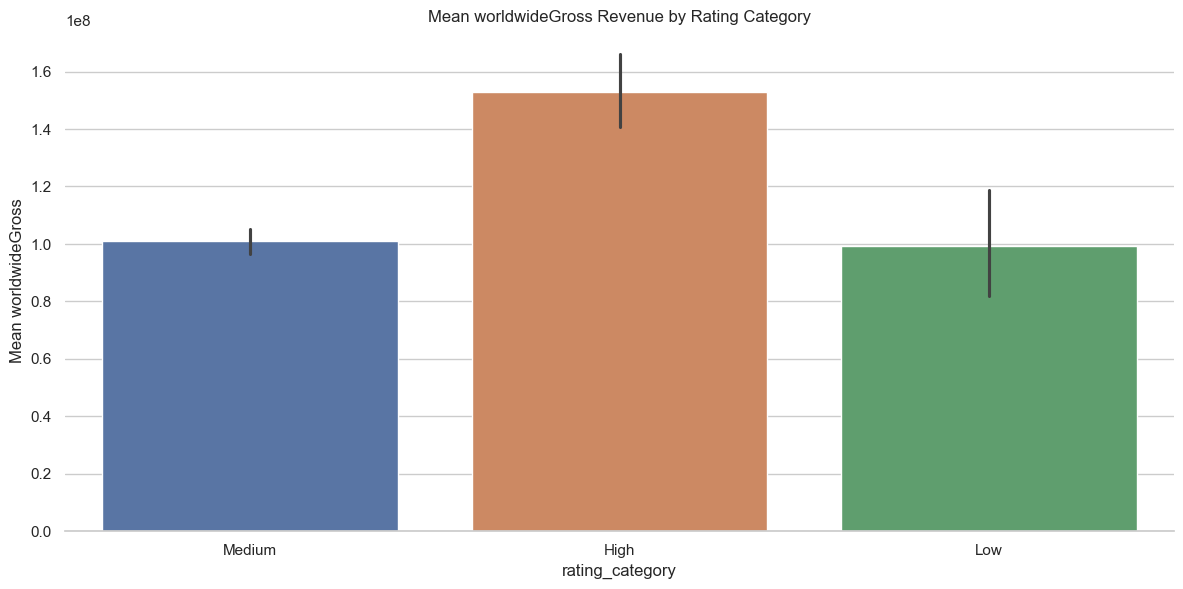

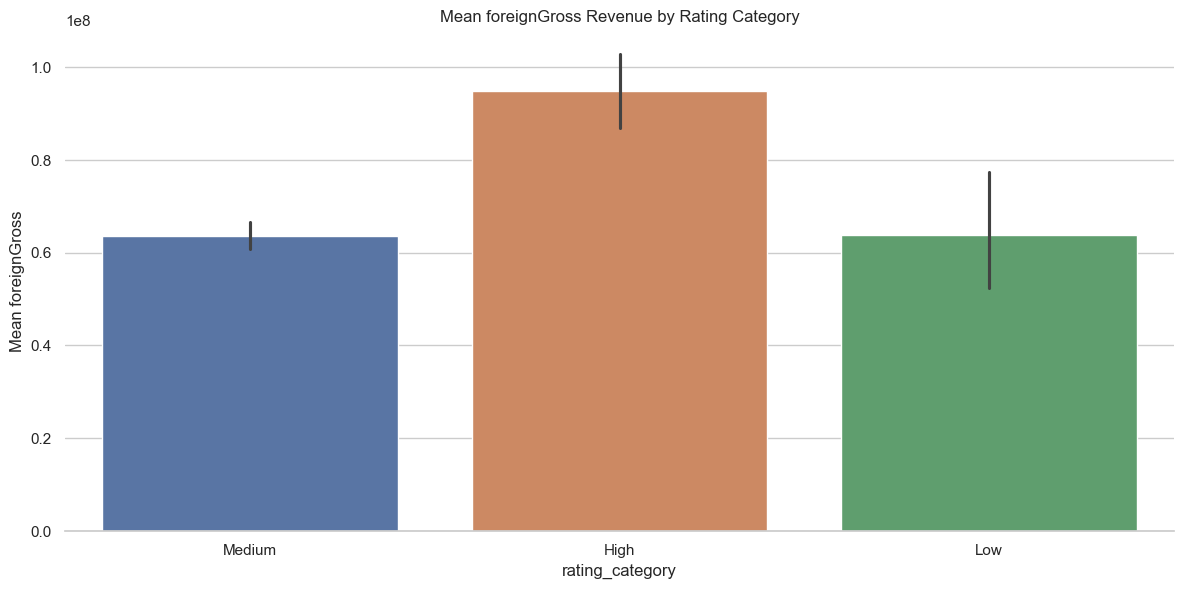

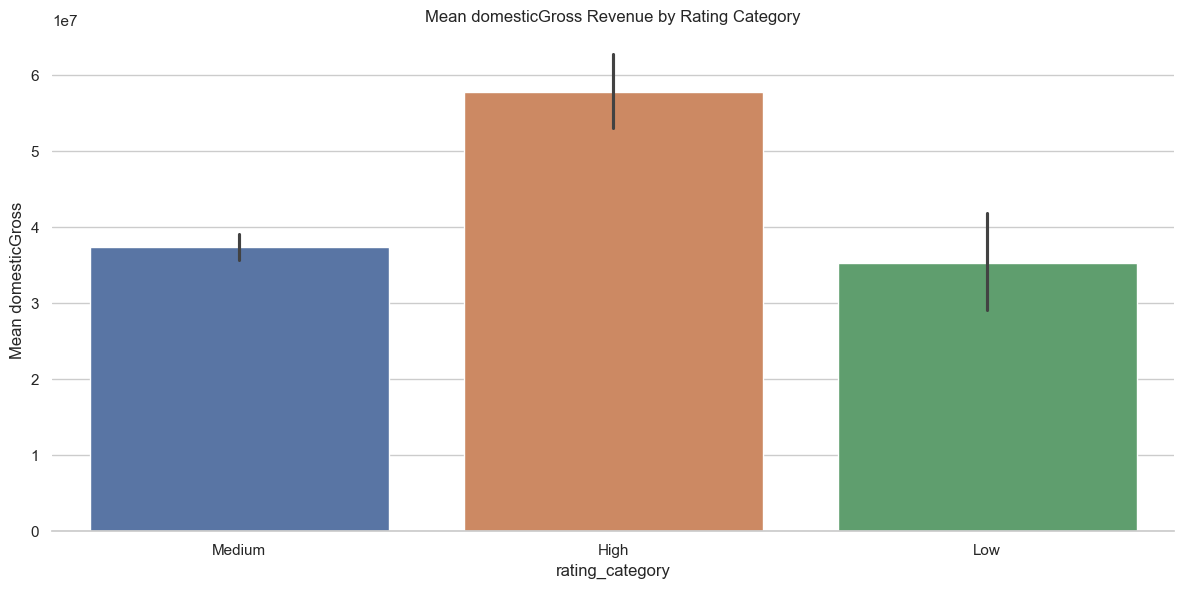

In [18]:
# create a  multi barchart representing the mean gross revenue for each rating category. There are 3 types of gross income (worldwide, foreign, domestic). I want a bar for each type of income for each rating category
def multi_barchart(df, x, y, hue):
    '''Creates a multi barchart'''
    sns.set(style="whitegrid")
    g = sns.catplot(x=x, y=y, hue=hue, data=df, kind="bar", height=6, aspect=2)
    g.despine(left=True)
    g.set_ylabels(f"Mean {y}")
    plt.title(f"Mean {y} Revenue by Rating Category")
    plt.show()

multi_barchart(movies, 'rating_category', 'worldwideGross', 'rating_category')
multi_barchart(movies, 'rating_category', 'foreignGross', 'rating_category')
multi_barchart(movies, 'rating_category', 'domesticGross', 'rating_category')

## Interpretation of Descriptive Statistics
The first generated dataframe presents general descriptive statistics of the movies data, displaying useful metrics such as mean, standard deviation, and the range of values for each numeric feature of the data. I also created print_median() functions to display the median values of each numeric feature. I then grouped the data by rating category (high/medium/low) and compared the descriptive statistics of this dataframe to the original dataframe.

#### isAdult
- This feature is a boolean representation of the adult movie categorization. The mean value is 0.00071, which means not many movies in this data are adult films. When grouped by rating category, I find that there are adult movies in the high and medium-rated categories and not the low-rated category.
#### runtimeMinutes
- The mean runtime of movies in this data is 104.7 minutes and the standard deviation is 28.9 minutes. This tells us that there is a large range of runtimes. High-rated movies have a higher mean runtime than medium-rated movies, and medium-rated movies have a higher mean runtime than low-rated movies.

#### IMDBavgRating
- The mean rating is 6.3, and the standard deviation is 1.1. From this, I can determine that a majority of movies are rated between 5 and 7. The mean average ratings for high-rated movies and medium-rated movies are close to the full sample mean.

#### Income metrics
- The gross income means for films (worldwide, foreign, and domestic) are in the millions, and the standard deviations are just as large. There is significant variation in these metrics. The median values for each type of gross income are significantly lower than the mean values, suggesting that there is a small number of movies making significantly more money than the others. High-rated movies have higher mean gross income levels than medium and low-rated movies. An interesting finding is that medium and low-rated movies have a similar mean foreign gross income level. Each rating category has similar proportions of foreign to domestic income (63:37).

- The visualization of gross revenue shows how similar gross revenue is for medium-rated and low-rated movies. High-rated movies seem to generate much more revenue than medium and low-rated movies.

### Inferential Statistics

#### Sub RQs
1. Is there a linear relationship between IMDB rating and gross income? What if I separate by rating category?
2. Do highly rated movies generate more revenue than medium-rated movies?
3. Do medium-rated movies generate more revenue than low-rated movies?

#### Testing Methods
- ANOVA: I will use this to compare gross income statistics between rating categories (high vs. medium vs. low).
- Regression Analysis: I will use this to determine if there is a significant relationship between rating and income level.

In [19]:
def find_corr(df, target='IMDBavgRating', columns=None):
    '''Finds the correlation between the target and specified columns''' 
    
    for column in columns:
        print(f"Correlation between {column} and rating")
        print(f"{df[target].corr(df[column])}\n")


find_corr(movies, columns=['domesticGross', 'worldwideGross', 'foreignGross'])

Correlation between domesticGross and rating
0.12208548145052531

Correlation between worldwideGross and rating
0.12235400956470854

Correlation between foreignGross and rating
0.11310184128713203



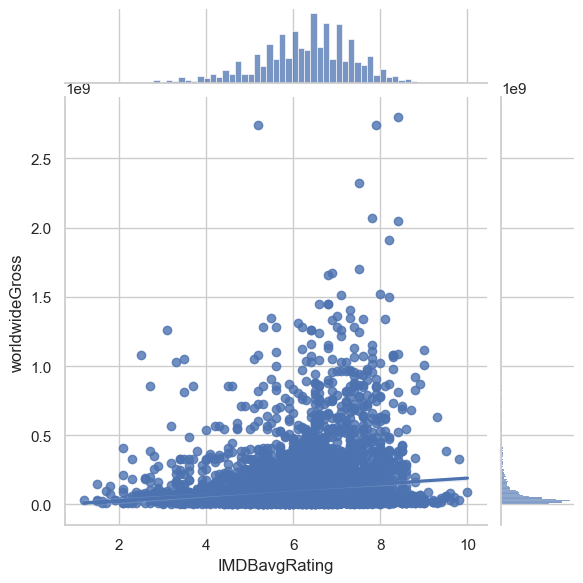

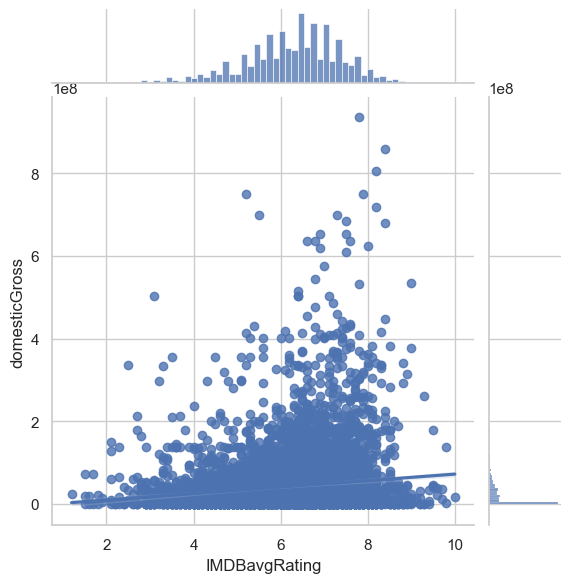

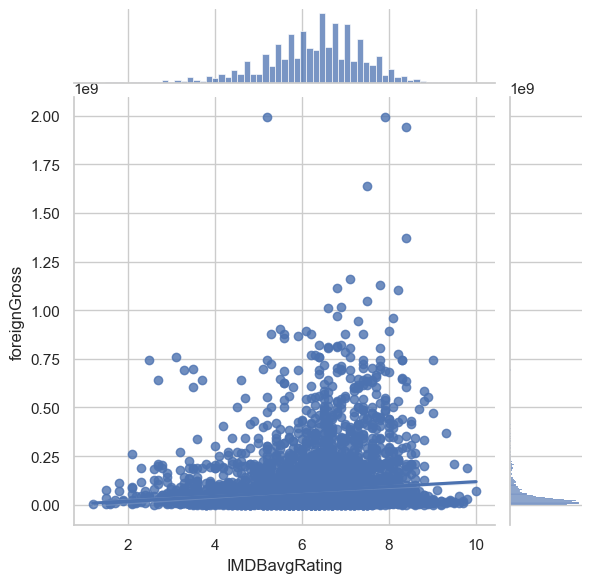

In [20]:
def generate_jointgrid(df, x, y):
    '''Generates a jointgrid with a scatterplot and histogram'''
    g = sns.JointGrid(data=df, x=x, y=y)
    g = g.plot(sns.regplot, sns.histplot)
    plt.show()

generate_jointgrid(movies, 'IMDBavgRating', 'worldwideGross')
generate_jointgrid(movies, 'IMDBavgRating', 'domesticGross')
generate_jointgrid(movies, 'IMDBavgRating', 'foreignGross')

### Interpretation

- I found the correlation between IMDB average rating and gross incomes, and I found a weak positive correlation between rating and each type of gross income. I expected there to be a stronger correlation, as I expect highly rated movies to make more money.
- The visualization shows the weak relationship between IMDB average rating and worldwide gross. Although the relationship is positive, I can't conclude that the relationship is definitive. I notice a high concentration of movies making less than 500 million gross worldwide, while a smaller quantity of data points north of this threshold is skewing the regression line.

In [21]:
low_ratings = movies[movies['rating_category'] == 'Low']
mid_ratings = movies[movies['rating_category'] == 'Medium']
high_ratings = movies[movies['rating_category'] == 'High']

groups = {"low rated": low_ratings, "mid rated": mid_ratings, "high rated": high_ratings}

for k, v in groups.items():
    print(k)
    find_corr(v, columns=['domesticGross', 'worldwideGross', 'foreignGross'])

low rated
Correlation between domesticGross and rating
-0.03639618093610432

Correlation between worldwideGross and rating
-0.06145625544629724

Correlation between foreignGross and rating
-0.0719194647850729

mid rated
Correlation between domesticGross and rating
0.07477188263533831

Correlation between worldwideGross and rating
0.0813949208088475

Correlation between foreignGross and rating
0.07689097613294835

high rated
Correlation between domesticGross and rating
0.0851073097020312

Correlation between worldwideGross and rating
0.10188714778508431

Correlation between foreignGross and rating
0.10662931715860635



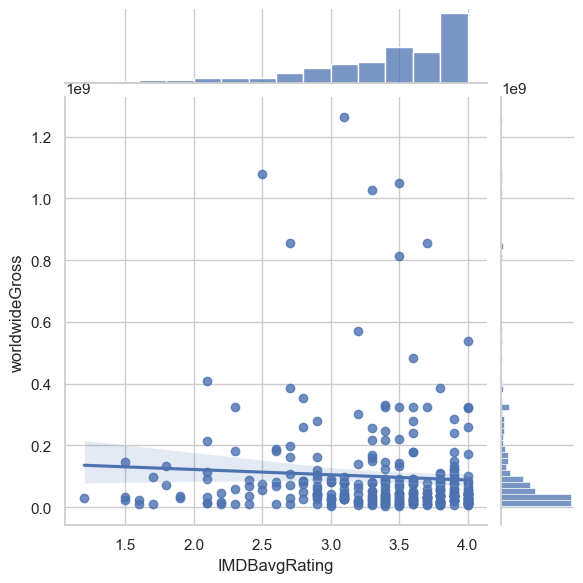

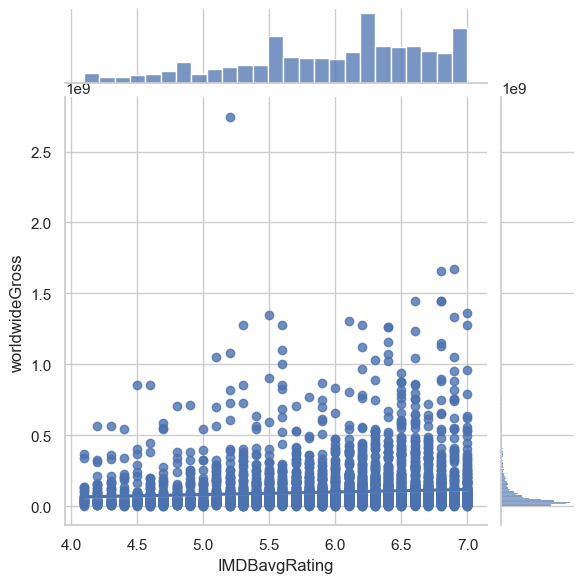

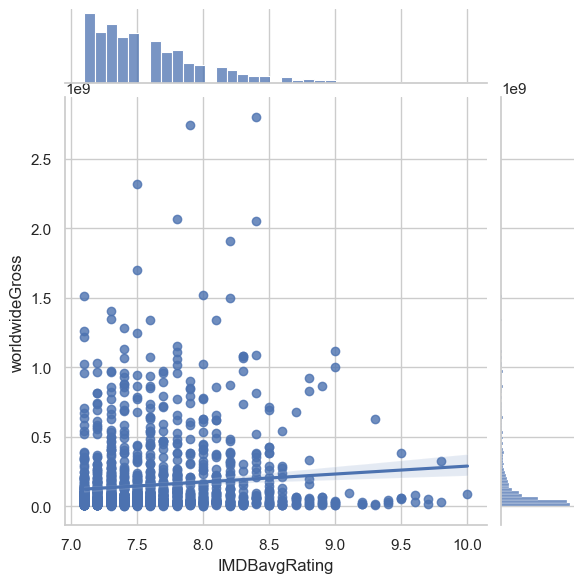

In [22]:
generate_jointgrid(low_ratings, 'IMDBavgRating', 'worldwideGross')
generate_jointgrid(mid_ratings, 'IMDBavgRating', 'worldwideGross')
generate_jointgrid(high_ratings, 'IMDBavgRating', 'worldwideGross')

### Interpretation

- After subsetting the data by rating category, I am still not finding a strong correlation between rating and gross income. The correlation between each rating category and type of gross income is weak.

- The joint grid visualizations demonstrate the same effect. These graphs show that movies with a 6-8.5 IMDB rating make the most money. Almost all movies in this dataset are making at least hundreds of millions of dollars, but some generate 5x-10x more than the rest, and IMDB ratings aren't predicting which will make the most money.

In [ ]:
def generate_ols_model(df, x=None, columns=None, y=None ):
    '''Generates an OLS model for the target and specified columns'''
    if columns:
        for column in columns:
            model = smf.ols(f"{column} ~ {x}", data=df).fit()
            print(model.summary())
    if y:
        model = smf.ols(f"{y} ~ {x}", data=df).fit()
        print(model.summary())

for k, v in groups.items():
    print(f"{k} OLS model\n")
    generate_ols_model(v, columns=['domesticGross', 'worldwideGross', 'foreignGross'], x='IMDBavgRating')

low rated OLS model

                            OLS Regression Results                            
Dep. Variable:          domesticGross   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4085
Date:                Tue, 18 Mar 2025   Prob (F-statistic):              0.523
Time:                        22:11:37   Log-Likelihood:                -5996.2
No. Observations:                 310   AIC:                         1.200e+04
Df Residuals:                     308   BIC:                         1.200e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      4.782e+07 

### Interpretation

- In the above cell, I created linear regression models to confirm what I found earlier about the correlations. The R-squared values are very low, meaning the model explains very little of the variance in gross income. Furthermore, the F-statistic for each model is high, meaning the results aren't statistically significant. A linear model doesn't quite explain the relationship between IMDB average rating and gross income.

In [24]:
def generate_anova(df, columns=None):
    '''Generates an ANOVA table for the specified columns'''
    for column in columns:
        model = smf.ols(f"{column} ~ rating_category", data=df).fit()
        table = sm.stats.anova_lm(model, typ=2)
        print(table)

generate_anova(movies, columns=['domesticGross', 'worldwideGross', 'foreignGross'])

                       sum_sq      df          F        PR(>F)
rating_category  5.525403e+17     2.0  51.563677  5.881829e-23
Residual         3.751027e+19  7001.0        NaN           NaN
                       sum_sq      df          F        PR(>F)
rating_category  3.500224e+18     2.0  48.571836  1.123388e-21
Residual         2.522559e+20  7001.0        NaN           NaN
                       sum_sq      df          F        PR(>F)
rating_category  1.272585e+18     2.0  39.789539  6.562906e-18
Residual         1.119561e+20  7001.0        NaN           NaN


### Interpretation
- Based on the ANOVA test, I find that there is a significant difference in mean gross income levels between different rating categories. I will next use Tukey's honestly significant differences (HSD) to determine which rating categories differ from each other.

In [25]:
def generate_HSD(df, columns=None):
    '''Generates a Tukey HSD test for the specified columns'''
    for column in columns:
        model = pairwise_tukeyhsd(df[column], df['rating_category'])
        print(model.summary())

generate_HSD(movies, columns=['domesticGross', 'worldwideGross', 'foreignGross'])

          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
group1 group2    meandiff    p-adj      lower          upper      reject
------------------------------------------------------------------------
  High    Low -22514668.2327    0.0 -33098407.1154 -11930929.3501   True
  High Medium -20459250.5958    0.0 -25251698.1629 -15666803.0287   True
   Low Medium   2055417.6369 0.8809  -7989767.1824  12100602.4562  False
------------------------------------------------------------------------
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
group1 group2    meandiff    p-adj      lower          upper      reject
------------------------------------------------------------------------
  High    Low -53627559.8721    0.0 -81073916.8517 -26181202.8925   True
  High Medium  -51736909.295    0.0 -64164958.4174 -39308860.1726   True
   Low Medium   1890650.5771 0.9842 -24159097.2042  27940398.3584  False
---------------------------------------------------

### Interpretation

#### Null Hypothesis
- There is no difference in worldwide, domestic, or foreign gross income between high, medium, and low-rated movies.

#### Alternative Hypothesis
- There is a difference in worldwide, domestic, or foreign gross income between high, medium, and low-rated movies.

#### p-value
- 0.05

#### Results
- Based on the HSD model, I find that I can reject the null hypothesis that high-rated movies and medium-rated movies have no difference in mean worldwide, domestic, and foreign gross incomes. I can also reject the null hypothesis that high-rated movies and low-rated movies have no difference in average worldwide, domestic, and foreign gross incomes. However, I cannot reject the null hypothesis that medium-rated movies and low-rated movies have statistically different incomes.

- These results confirm what I found in the earlier visualization of mean gross income per rating category. High-rated movies make significantly more money than medium and low-rated movies.

In [26]:
generate_ols_model(movies, x='IMDBavgRating * worldwideGross', y='rank')
generate_ols_model(movies, x='worldwideGross', y='rank')

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     1563.
Date:                Tue, 18 Mar 2025   Prob (F-statistic):               0.00
Time:                        22:11:56   Log-Likelihood:                -36373.
No. Observations:                7004   AIC:                         7.275e+04
Df Residuals:                    7000   BIC:                         7.278e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

#### Interpretation
- I conducted an additional regression analysis to find out if movie ranking can be predicted by IMDB rating and/or worldwide income. I found a strong interaction effect between IMDB rating and worldwide gross income on the ranking outcome. As income increases, the rank decreases (rank 1 is the best), and as IMDB rating increases, the rank also decreases. When these terms interact, the effect of the dependent variables becomes even stronger. According to the model, as IMDB rating increases, the effect of worldwide gross income becomes stronger on the rank of the movie. Highly rated movies with high levels of worldwide income have very low rankings.

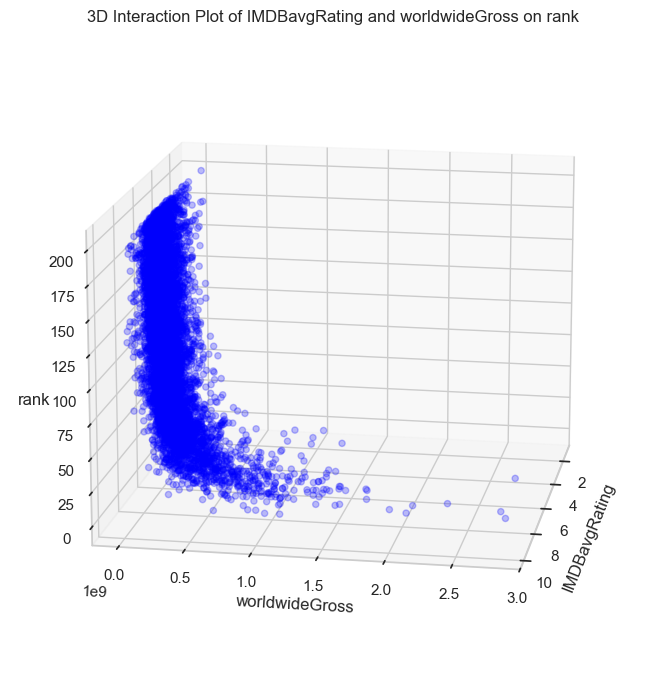

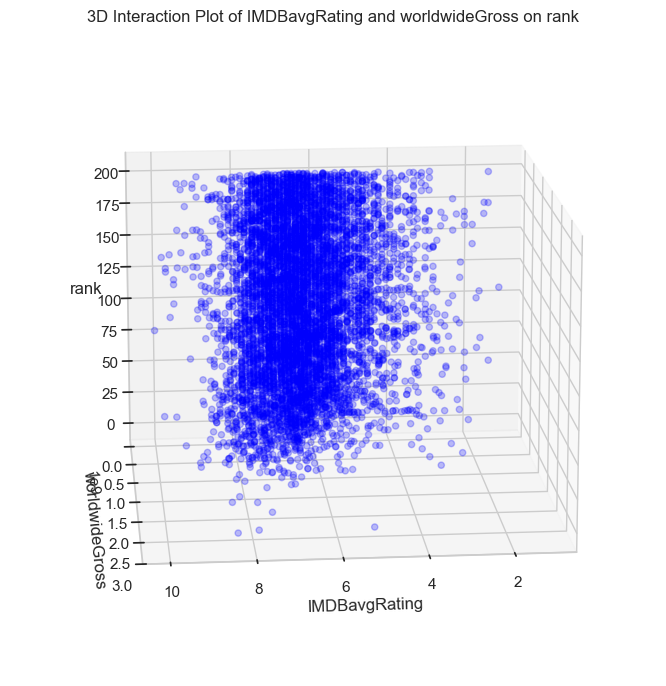

In [27]:
X = movies[['IMDBavgRating', 'worldwideGross']]
y = movies['rank']
model = LinearRegression().fit(X, y)

# Create grid to plot over
x_surf, y_surf = np.meshgrid(np.linspace(movies['IMDBavgRating'].min(), movies['IMDBavgRating'].max(), 100),
                             np.linspace(movies['worldwideGross'].min(), movies['worldwideGross'].max(), 100))
z_surf = model.predict(np.array([x_surf.ravel(), y_surf.ravel()]).T).reshape(x_surf.shape)

# Plotting
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(movies['IMDBavgRating'], movies['worldwideGross'], movies['rank'], color='blue', alpha=0.25)
# ax.plot_surface(x_surf, y_surf, z_surf, color='None', edgecolor='grey', alpha=0.5)

ax.set_xlabel('IMDBavgRating')
ax.set_ylabel('worldwideGross')
ax.set_zlabel('rank')
ax.set_title('3D Interaction Plot of IMDBavgRating and worldwideGross on rank')
ax.view_init(elev=15, azim=10)

plt.tight_layout(pad=10)
plt.show()

x_surf, y_surf = np.meshgrid(np.linspace(movies['IMDBavgRating'].min(), movies['IMDBavgRating'].max(), 100),
                             np.linspace(movies['worldwideGross'].min(), movies['worldwideGross'].max(), 100))
z_surf = model.predict(np.array([x_surf.ravel(), y_surf.ravel()]).T).reshape(x_surf.shape)

# Plotting
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(movies['IMDBavgRating'], movies['worldwideGross'], movies['rank'], color='blue', alpha=0.25)
# ax.plot_surface(x_surf, y_surf, z_surf, color='None', edgecolor='grey', alpha=0.5)

ax.set_xlabel('IMDBavgRating')
ax.set_ylabel('worldwideGross')
ax.set_zlabel('rank')
ax.set_title('3D Interaction Plot of IMDBavgRating and worldwideGross on rank')
ax.view_init(elev=15, azim=85)

plt.tight_layout(pad=10)
plt.show()

### Interpretation
- The above visualizations were generated with the help of UMGPT. The 3D graphs display the interaction effect of IMDB average rating and worldwide gross for predicting rank. As IMDB rating and worldwide gross increase, the ranking comes closer to 0. This follows the interaction term found in the previous linear model, and it makes logical sense that movies with high ratings and high income have the best rankings.

## Reflection
- Overall, there are differences in income across rating levels. Highly-rated movies, on average, generate more revenue than medium and low-rated movies. Additionally, there is an interesting interaction between worldwide gross income and IMDB average score when predicting rank. I was hoping to find more significant relationships between rating and gross income, but it is clear to me now that score is not an indicator of box office success, at least not on its own.

# Tyrone Analysis

### Descriptive Statistics

- Provide a comprehensive summary of your combined dataset using descriptive statistics. This should include means, medians, modes, ranges, variance, and standard deviations for the relevant features of your data. The descriptive statistics should inform your guiding questions that you developed in Part I of the project, rather than merely providing an overview of your data. Interpret these results to draw preliminary conclusions about the data.

In [ ]:
# Filter movies with more than 200k votes
movies_200k_votes = movies[movies['numVotes'] >= 200000]

# Columns to include in the new DataFrame
columns_to_select = ['title', 'year', 'main_genre', 'worldwideGross', 'domesticGross', 'domestic%', 'foreignGross', 'foreign%']

# Create a new DataFrame by selecting the specified columns
genre_income = movies_200k_votes[columns_to_select]

# Display the new DataFrame
print(genre_income.columns)

Index(['title', 'year', 'main_genre', 'worldwideGross', 'domesticGross',
       'domestic%', 'foreignGross', 'foreign%'],
      dtype='object')


In [ ]:
# Group by 'main_genre' without aggregation
genre_grouped = genre_income.groupby('main_genre')

# Iterate over each group
for genre, group_data in genre_grouped:
    print(f"\nGenre: {genre}")

    # Display the first 5 rows of each group
    print(genre_grouped.head(5))


Genre: Action
                                                  title  year main_genre  \
2                                        Fantastic Four  2005     Action   
3                                        Fantastic Four  2015     Action   
6     The Lord of the Rings: The Fellowship of the Ring  2001  Adventure   
7                                         Resident Evil  2002     Action   
10                                      Men in Black II  2002     Action   
11                                         Corpse Bride  2005  Animation   
12         Star Wars: Episode II - Attack of the Clones  2002     Action   
15                                                Shrek  2001  Adventure   
21                                         Training Day  2001      Crime   
40                                     Mulholland Drive  2001      Drama   
43        The Lord of the Rings: The Return of the King  2003  Adventure   
44                The Lord of the Rings: The Two Towers  2002  Adventure 

In [ ]:
def print_group_stats(df):
    '''Print the grouped statistics for each genre'''
    for column in df.select_dtypes(include=np.number).columns:
        print(f"\n{column} Statistics:")
        print(df.groupby('main_genre')[column].describe().round(1))

print_group_stats(genre_income)


year Statistics:
            count    mean  std     min     25%     50%     75%     max
main_genre                                                            
Action      399.0  2012.4  5.9  2001.0  2008.0  2013.0  2017.0  2024.0
Adventure   112.0  2010.2  5.7  2001.0  2005.8  2010.0  2014.0  2024.0
Animation     6.0  2013.2  5.7  2005.0  2009.8  2014.0  2016.0  2021.0
Biography    51.0  2011.8  5.7  2001.0  2007.5  2013.0  2016.0  2023.0
Comedy      116.0  2009.2  5.2  2001.0  2004.8  2009.0  2012.0  2024.0
Crime        55.0  2009.1  5.7  2001.0  2005.0  2007.0  2013.0  2023.0
Drama       104.0  2011.3  5.9  2001.0  2006.0  2011.0  2016.0  2024.0
Fantasy       2.0  2004.0  4.2  2001.0  2002.5  2004.0  2005.5  2007.0
Horror       31.0  2012.9  6.6  2001.0  2007.0  2013.0  2017.0  2024.0
Mystery       4.0  2006.2  2.5  2003.0  2005.2  2006.5  2007.5  2009.0
Sci-Fi        2.0  2009.0  2.8  2007.0  2008.0  2009.0  2010.0  2011.0

worldwideGross Statistics:
            count         mean 

### Inferential Statistics

- Conduct appropriate hypothesis tests to investigate if there are significant differences or correlations within your data. This might involve regression analysis, ANOVA, and/or chi-squared tests.

- Clearly state your null and alternative hypotheses, choose an appropriate significance level, and discuss your findings. Make sure to justify the choice of your tests.

ANOVA Results:
                      sum_sq     df         F        PR(>F)
C(main_genre)  2.069096e+19   10.0  20.38187  3.514854e-34
Residual       8.842085e+19  871.0       NaN           NaN


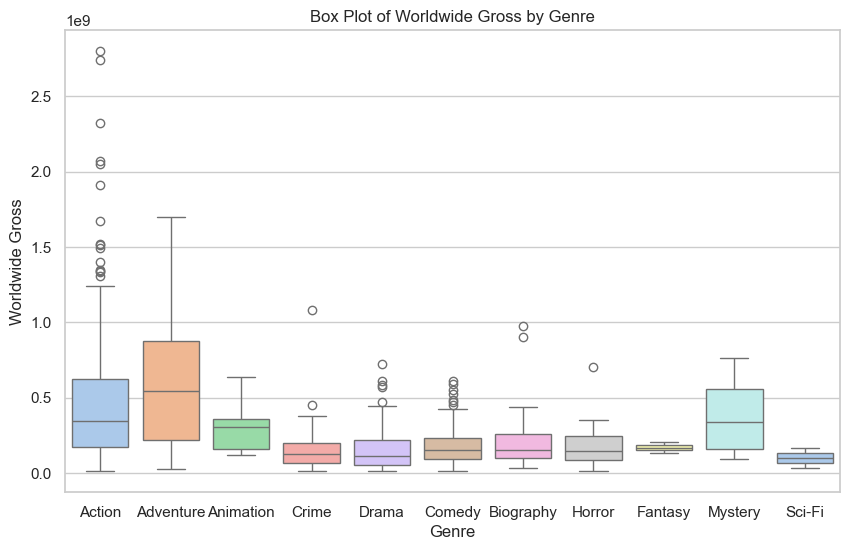

In [ ]:
### ANOVA: Test if `worldwideGross` differs significantly across `main_genre`
anova_model = ols('worldwideGross ~ C(main_genre)', data=genre_income).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print("ANOVA Results:\n", anova_table)

# Box Plot of Foreign Gross by Genre
plt.figure(figsize=(10, 6))
sns.boxplot(data=genre_income, x='main_genre', y='worldwideGross', palette='pastel')
plt.title('Box Plot of Worldwide Gross by Genre')
plt.xlabel('Genre')
plt.ylabel('Worldwide Gross')
plt.show()

### Interpretation

- Action has many outliers for worldwide gross.
- Mystery has a higher median than many other genres.

## Chi-Square Test


<Figure size 1000x600 with 0 Axes>

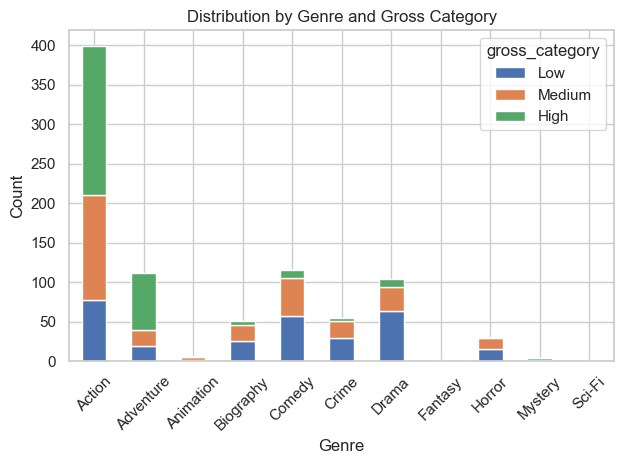

In [ ]:
# Bin worldwideGross into 3 categories (Low, Medium, High)
genre_income['gross_category'] = pd.qcut(genre_income['worldwideGross'], q=3, labels=['Low', 'Medium', 'High'])

# Create a contingency table that counts the gross_category for each production country
contingency_table = pd.crosstab(genre_income['main_genre'], genre_income['gross_category'])



plt.figure(figsize=(10,6))
contingency_table.plot(kind='bar', stacked=True)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Distribution by Genre and Gross Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(contingency_table)

gross_category  Low  Medium  High
main_genre                       
Action           78     133   188
Adventure        19      21    72
Animation         2       3     1
Biography        26      20     5
Comedy           57      48    11
Crime            29      22     4
Drama            64      30    10
Fantasy           1       1     0
Horror           16      14     1
Mystery           1       1     2
Sci-Fi            1       1     0


### Interpretation
- It is observed that Mystery only has 4 movies, and 2 of them are in the high category, which is why the median is higher than in other genres.
- The majority of movies that are high-grossing belong to the Action genre.

### Graphical Analysis


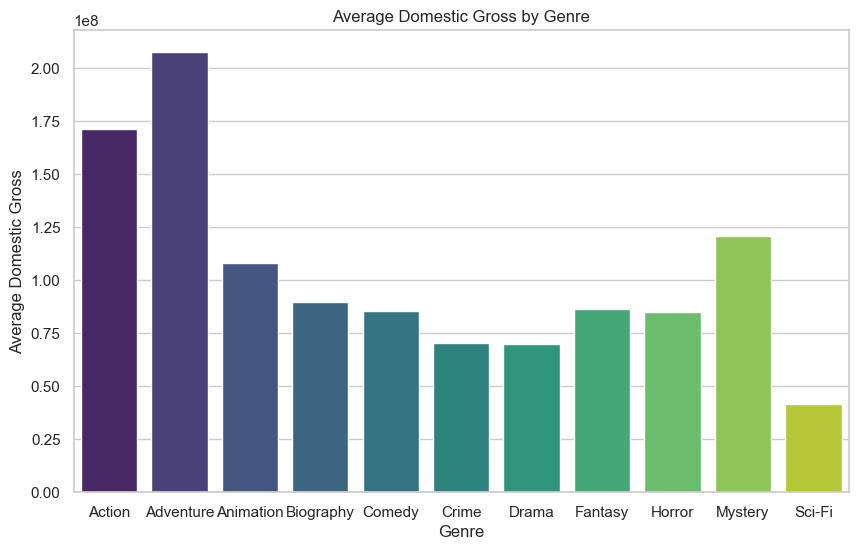

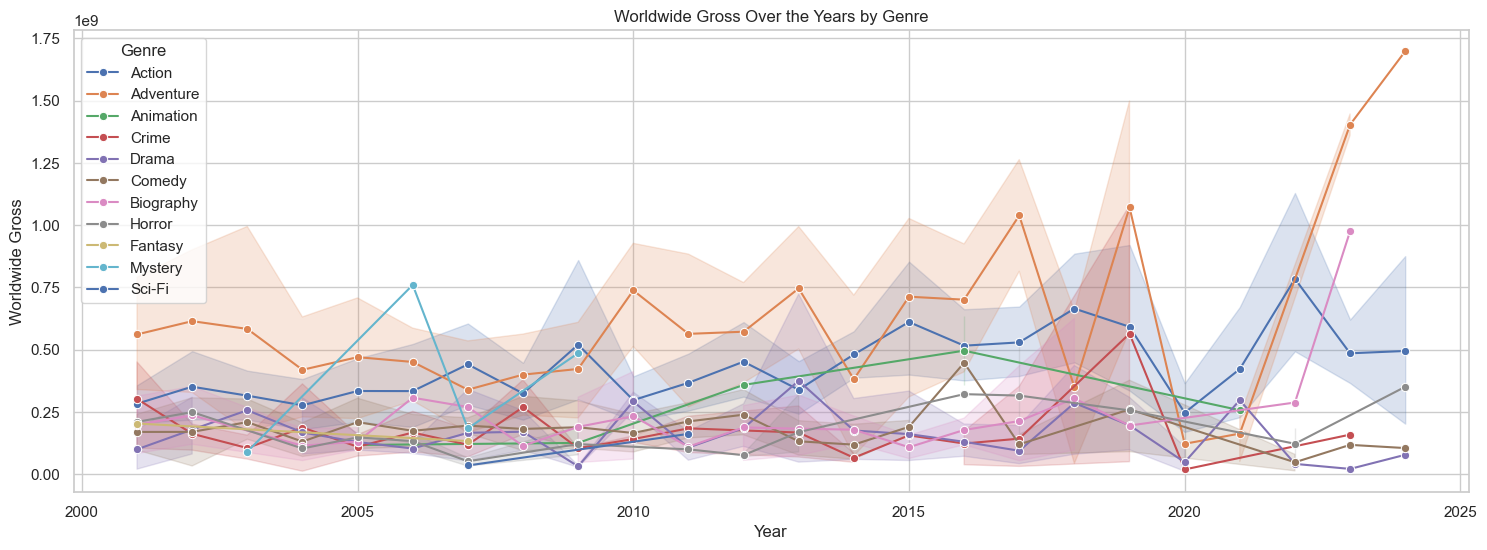

In [ ]:
# Bar Chart of Average Domestic Gross by Genre
avg_domestic_gross_by_genre = genre_income.groupby('main_genre')['domesticGross'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_domestic_gross_by_genre, x='main_genre', y='domesticGross', palette='viridis')
plt.title('Average Domestic Gross by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Domestic Gross')
plt.show()


# Line Plot of Worldwide Gross Over the Years for Each Genre
plt.figure(figsize=(18, 6))
sns.lineplot(data=genre_income, x='year', y='worldwideGross', hue='main_genre', marker='o', palette='deep')
plt.title('Worldwide Gross Over the Years by Genre')
plt.xlabel('Year')
plt.ylabel('Worldwide Gross')
plt.legend(title='Genre')
plt.grid(True)
plt.show()

### Interpretation
- The Adventure genre has a higher mean than other genres.
- The line plot clearly shows the effect of the COVID-19 pandemic on worldwide gross.


### Comparative Analysis

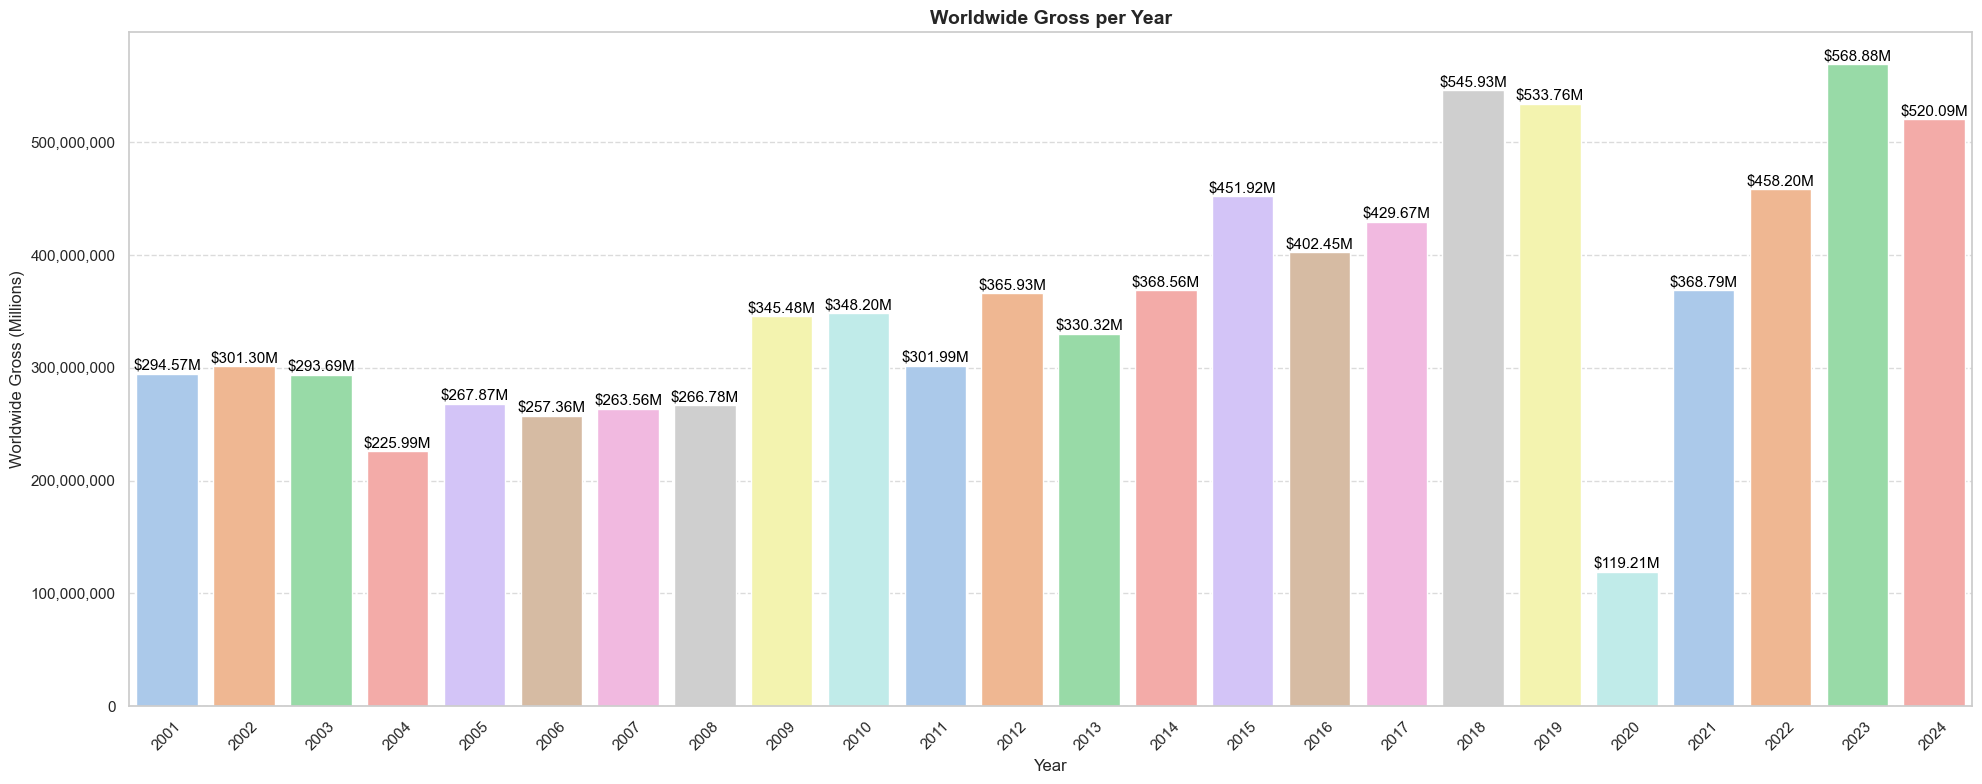

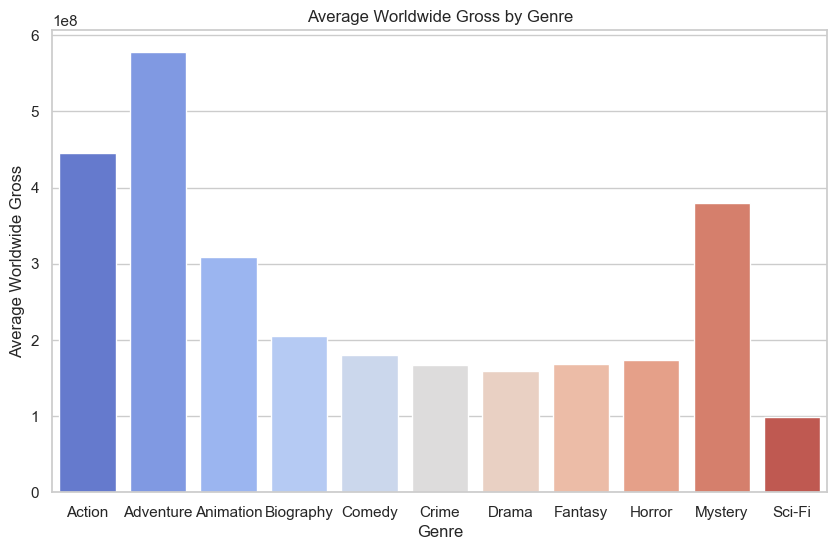

In [ ]:
# Enhanced Bar Plot with Labels in Millions
plt.figure(figsize=(20, 8))
ax = sns.barplot(data=genre_income, x='year', y='worldwideGross', ci=None, palette='pastel')
plt.title('Worldwide Gross per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Worldwide Gross (Millions)', fontsize=12)
plt.xticks(rotation=45)

# Add data labels in millions
for p in ax.patches:
    ax.annotate(f"${p.get_height()/1e6:,.2f}M",  # Converts to millions and formats
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 3),
                textcoords='offset points')

# Use commas in Y-axis labels for readability
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Adding gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Comparison 2: Across Genres
# Compare average worldwide gross by genre
avg_worldwide_gross_by_genre = genre_income.groupby('main_genre')['worldwideGross'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_worldwide_gross_by_genre, x='main_genre', y='worldwideGross', palette='coolwarm')
plt.title('Average Worldwide Gross by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Worldwide Gross')
plt.show()

### Interpretation

- It took 3 years for the worldwide gross to return to pre-COVID-19 pandemic levels.
- The mean worldwide gross for the Adventure genre is also the highest among genres.

### Multivariate Analysis


Pivot Table:
year                2001          2002          2003          2004  \
main_genre                                                           
Action      2.829993e+08  3.512025e+08  3.153443e+08  2.764721e+08   
Adventure   5.612269e+08  6.145990e+08  5.833910e+08  4.191490e+08   
Animation            NaN           NaN           NaN           NaN   
Biography   1.984123e+08  2.360934e+08           NaN  1.141086e+08   
Comedy      1.695670e+08  1.697890e+08  2.090516e+08  1.307768e+08   
Crime       3.024286e+08  1.622019e+08  1.049534e+08  1.872972e+08   
Drama       9.966539e+07  1.790105e+08  2.566975e+08  1.675496e+08   
Fantasy     2.033883e+08           NaN           NaN           NaN   
Horror      2.099470e+08  2.493489e+08           NaN  1.030963e+08   
Mystery              NaN           NaN  9.025954e+07           NaN   
Sci-Fi               NaN           NaN           NaN           NaN   

year                2005          2006          2007          2008  \
main_g

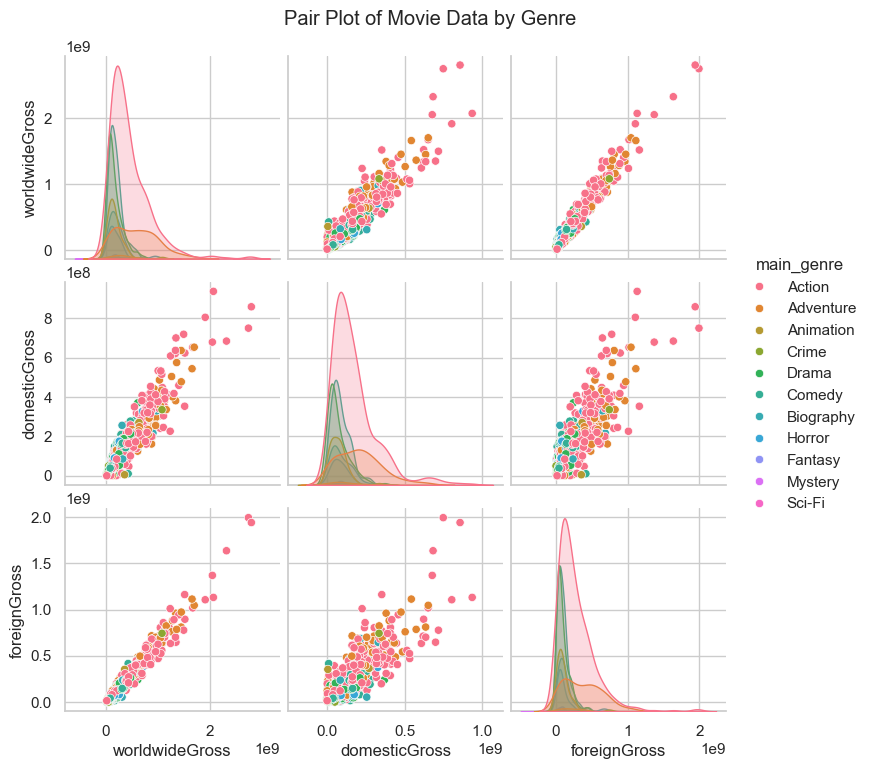

In [ ]:
### Cross-tabulation with Pivot Table
# Pivot table for average worldwide gross by genre and year
pivot_table = pd.pivot_table(genre_income, values='worldwideGross', index='main_genre', columns='year', aggfunc='mean')
print("Pivot Table:")
print(pivot_table)

### Multivariate Graph: Pair Plot

new_df = genre_income[['worldwideGross', 'domesticGross', 'foreignGross', 'main_genre']]

# Pair plot to explore relationships between numeric variables
sns.pairplot(new_df, hue='main_genre')
plt.suptitle('Pair Plot of Movie Data by Genre', y=1.02)
plt.show()

### Interpretation
- As foreign gross increases, worldwide gross increases.
- Domestic gross is correlated with foreign gross.